# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [1]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [98]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [99]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

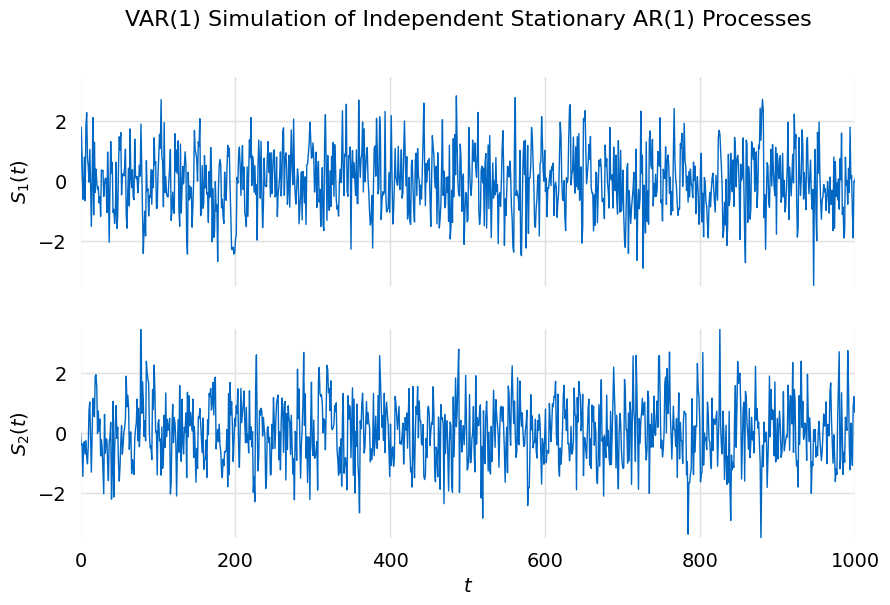

In [100]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [101]:
result = var.compute_estimate(xt, maxlags=nlag)

2 2
[-0.02882963  0.00716942]
[0.01424734 0.01445493]
[[[ 0.24608354 -0.00556547]
  [ 0.00545514  0.24239114]]

 [[-0.00212207  0.01303882]
  [-0.00807     0.01293613]]]
[[[0.01414714 0.01395122]
  [0.01435327 0.01415449]]

 [[0.01414788 0.01395185]
  [0.01435402 0.01415513]]]
[[1.         0.00277218]
 [0.00277218 1.        ]]


In [103]:
result.resid_corr

array([[1.        , 0.00277218],
       [0.00277218, 1.        ]])

In [106]:
result.coefs

array([[[ 0.24608354, -0.00556547],
        [ 0.00545514,  0.24239114]],

       [[-0.00212207,  0.01303882],
        [-0.00807   ,  0.01293613]]])

In [105]:
result.params, result.stderr

(             S0        S1
 const -0.028830  0.007169
 L1.S0  0.246084  0.005455
 L1.S1 -0.005565  0.242391
 L2.S0 -0.002122 -0.008070
 L2.S1  0.013039  0.012936,
              S0        S1
 const  0.014247  0.014455
 L1.S0  0.014147  0.014353
 L1.S1  0.013951  0.014154
 L2.S0  0.014148  0.014354
 L2.S1  0.013952  0.014155)

In [102]:
result.params.loc['const'].to_numpy(), result.stderr.loc['const'].to_numpy()

(array([-0.02882963,  0.00716942]), array([0.01424734, 0.01445493]))

In [95]:
params = result.params.iloc[1:].to_numpy()
stderr = result.stderr.iloc[1:].to_numpy()
params, stderr

(array([[ 0.26641864,  0.02033019],
        [ 0.01175232,  0.23832306],
        [-0.01794261, -0.00697561],
        [-0.01463253,  0.00843076]]),
 array([[0.01415508, 0.01443446],
        [0.01388023, 0.01415419],
        [0.01415897, 0.01443843],
        [0.01387849, 0.01415241]]))

In [97]:
[numpy.transpose(a) for a in numpy.array_split(params, 2)], [numpy.transpose(a) for a in numpy.array_split(stderr, 2)]

([array([[0.26641864, 0.01175232],
         [0.02033019, 0.23832306]]),
  array([[-0.01794261, -0.01463253],
         [-0.00697561,  0.00843076]])],
 [array([[0.01415508, 0.01388023],
         [0.01443446, 0.01415419]]),
  array([[0.01415897, 0.01387849],
         [0.01443843, 0.01415241]])])

In [13]:
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 04, Sep, 2023
Time:                     16:21:09
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0247740
Nobs:                     4998.00    HQIC:                 0.0163052
Log likelihood:          -14203.0    FPE:                    1.01180
AIC:                    0.0117352    Det(Omega_mle):         1.00978
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.031373         0.014198            2.210           0.027
L1.S0         0.232864         0.014145           16.463           0.000
L1.S1        -0.030092         0.014150           -2.127           0.033
L2.S0         0.010932

### Coupled $\text{AR}(1)$

In [58]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

True

In [59]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

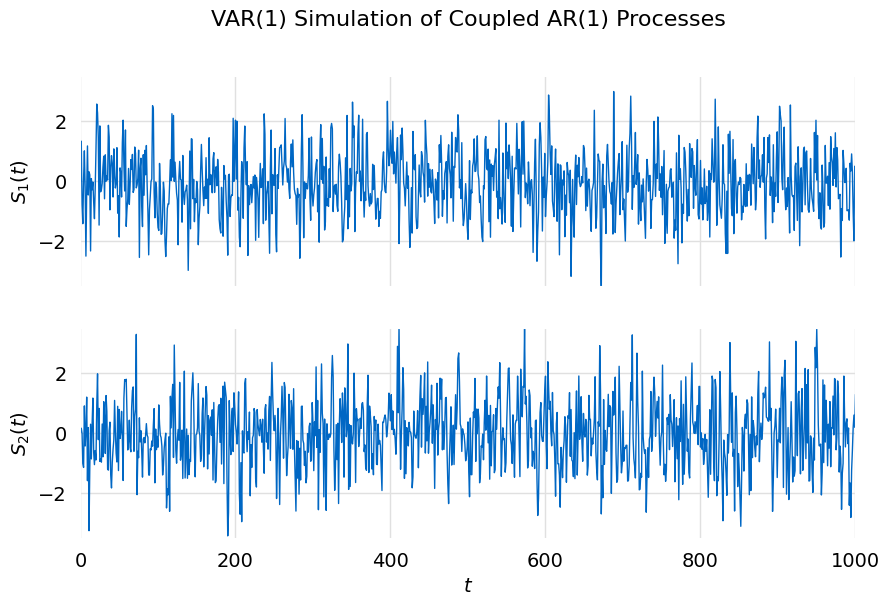

In [60]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [61]:
result = var.compute_estimate(xt, maxlags=1)

In [62]:
result.coefs

array([[[0.24952068, 0.04992894],
        [0.50834928, 0.14846283]]])

In [64]:
result.params

,S0,S1
const,-0.026322,0.011289
L1.S0,0.249521,0.508349
L1.S1,0.049929,0.148463


In [65]:
result.params.loc['const'].to_numpy()

array([-0.02632175,  0.01128908])

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [ ]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

In [ ]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

In [ ]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

### Coupled $\text{AR}(2)$

In [ ]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)

In [ ]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

In [ ]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [ ]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=11

In [ ]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

In [ ]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

### Coupled $\text{AR}(3)$

In [ ]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)


In [ ]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

In [ ]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))